<a href="https://colab.research.google.com/github/rohinisahu2789-ai/QuickPay-Fintech-Analysis/blob/main/AI_in_Financial_Risk_Management_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AI in Financial Risk Management  
We will build an AI model that predicts whether a credit card customer may default next month. Then we will convert model probabilities into risk bands and simple stress-scenario losses.


In [ ]:
# Install dataset loader
!pip -q install ucimlrepo

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Dataset loader
from ucimlrepo import fetch_ucirepo

# Scikit-learn tools
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Fetch UCI dataset by ID
credit_data = fetch_ucirepo(id=350)

X_raw = credit_data.data.features.copy()
y_raw = credit_data.data.targets.copy()

# Clean target into a simple Series
if isinstance(y_raw, pd.DataFrame):
    y_series = y_raw.iloc[:, 0].copy()
else:
    y_series = pd.Series(y_raw)

# Remove any ID column if present
X_raw.columns = [str(c).strip().lower() for c in X_raw.columns]
if "id" in X_raw.columns:
    X_raw = X_raw.drop(columns=["id"])

# Standard UCI feature names in correct order
standard_feature_names = [
    "limit_bal", "sex", "education", "marriage", "age",
    "pay_0", "pay_2", "pay_3", "pay_4", "pay_5", "pay_6",
    "bill_amt1", "bill_amt2", "bill_amt3", "bill_amt4", "bill_amt5", "bill_amt6",
    "pay_amt1", "pay_amt2", "pay_amt3", "pay_amt4", "pay_amt5", "pay_amt6"
]

if X_raw.shape[1] == len(standard_feature_names):
    X_raw.columns = standard_feature_names
else:
    X_raw.columns = (
        X_raw.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

df = X_raw.copy()
df["default_next_month"] = pd.to_numeric(y_series, errors="coerce").astype(int)

print("Shape:", df.shape)
print("\nColumns:")
print(list(df.columns))

display(df.head())

Shape: (30000, 24)

Columns:
['limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'default_next_month']


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   limit_bal           30000 non-null  int64
 1   sex                 30000 non-null  int64
 2   education           30000 non-null  int64
 3   marriage            30000 non-null  int64
 4   age                 30000 non-null  int64
 5   pay_0               30000 non-null  int64
 6   pay_2               30000 non-null  int64
 7   pay_3               30000 non-null  int64
 8   pay_4               30000 non-null  int64
 9   pay_5               30000 non-null  int64
 10  pay_6               30000 non-null  int64
 11  bill_amt1           30000 non-null  int64
 12  bill_amt2           30000 non-null  int64
 13  bill_amt3           30000 non-null  int64
 14  bill_amt4           30000 non-null  int64
 15  bill_amt5           30000 non-null  int64
 16  bill_amt6           30000 non-null  int6

In [ ]:
df[['limit_bal','sex','education','marriage','age']].describe()

,limit_bal,sex,education,marriage,age
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500
std,129747.661567,0.489129,0.790349,0.521970,9.217904
min,10000.000000,1.000000,0.000000,0.000000,21.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000


In [ ]:
df['education'].value_counts().sort_index()

,count
education,
0,14
1,10585
2,14030
3,4917
4,123
5,280
6,51


In [ ]:
df['marriage'].value_counts().sort_index()

,count
marriage,
0,54
1,13659
2,15964
3,323


In [ ]:
df=df.drop(df[df['marriage']==0].index)
df=df.drop(df[df['education']==0].index)
df=df.drop(df[df['education']==5].index)
df=df.drop(df[df['education']==6].index)

df.shape[0]

29601

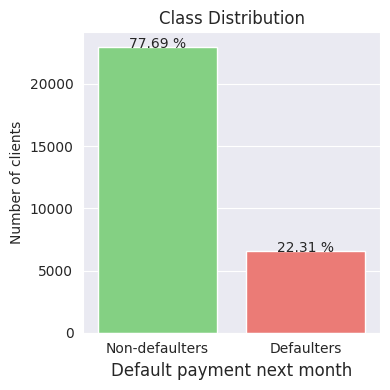

In [ ]:
plt.figure(figsize = (4,4))
graph_target = sns.countplot(x="default_next_month", data=df, palette=['#77DD76','#FF6962'])

i=0
for p in graph_target.patches:
    height = p.get_height()

    percentage = round(100 * df["default_next_month"].value_counts()[i] / len(df),2)

    str_plot = f'{percentage} %'

    graph_target.text(p.get_x()+p.get_width()/2., height - 100, str_plot, ha="center")
    i += 1

plt.title('Class Distribution')
plt.xticks([0,1],['Non-defaulters', 'Defaulters'])
plt.xlabel('Default payment next month', fontsize=12)
plt.ylabel('Number of clients')
plt.tight_layout()


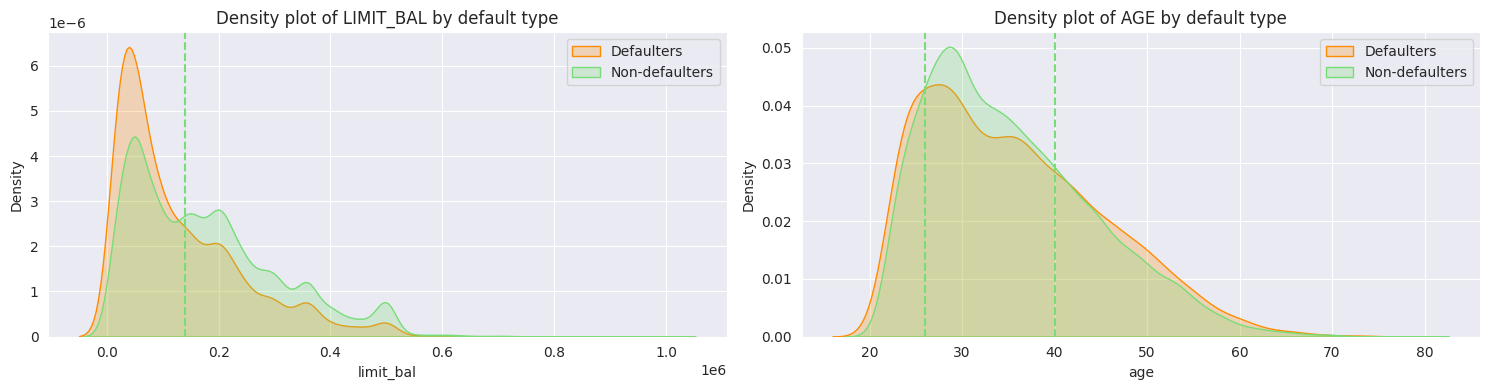

In [ ]:
# Kernel density distribution

import seaborn as sns

sns.set_palette(palette=['#77DD76', '#FF6962'])
fig, axs = plt.subplots(1, 2, figsize=(15, 4))

# LIMIT_BAL distribution
class_0 = df.loc[df['default_next_month'] == 0]['limit_bal']
class_1 = df.loc[df['default_next_month'] == 1]['limit_bal']

axs[0].set_title('Density plot of LIMIT_BAL by default type')
sns.kdeplot(class_1, fill=True, label='Defaulters', color='darkorange', ax=axs[0])
sns.kdeplot(class_0, fill=True, label='Non-defaulters', ax=axs[0])
axs[0].axvline(0.14 * 1e6, 0, ls='--')
axs[0].legend()

# AGE distribution
class_0 = df.loc[df['default_next_month'] == 0]['age']
class_1 = df.loc[df['default_next_month'] == 1]['age']

axs[1].set_title('Density plot of AGE by default type')
sns.kdeplot(class_1, fill=True, label='Defaulters', color='darkorange', ax=axs[1])
sns.kdeplot(class_0, fill=True, label='Non-defaulters', ax=axs[1])
axs[1].axvline(26, 0, ls='--')
axs[1].axvline(40, 0, ls='--')
axs[1].legend()

fig.tight_layout()

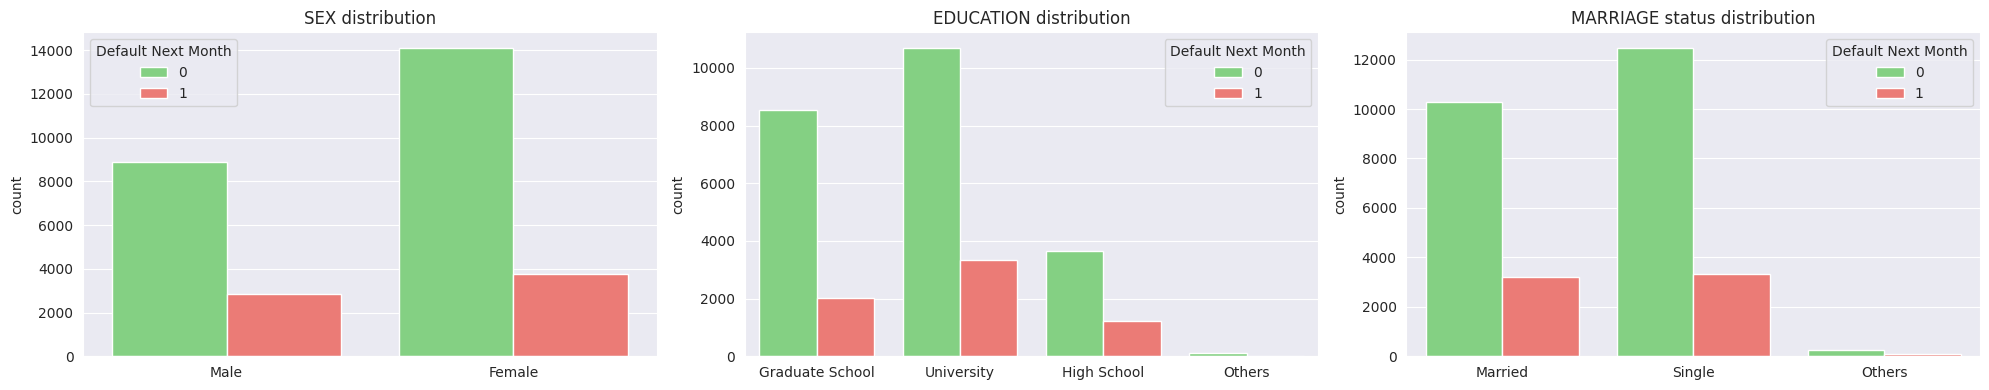

In [ ]:
sns.set_palette(palette=['#77DD76', '#FF6962'])
fig, axs = plt.subplots(1, 3, figsize=(20, 4))

# SEX distribution
axs[0].set_title('SEX distribution')
sns.countplot(x='sex', hue='default_next_month', data=df, ax=axs[0])
axs[0].set_xticklabels(['Male', 'Female'])
axs[0].set_xlabel('')
axs[0].legend(title='Default Next Month')

# EDUCATION distribution
axs[1].set_title('EDUCATION distribution')
sns.countplot(x='education', hue='default_next_month', data=df, ax=axs[1])
axs[1].set_xticklabels(['Graduate School', 'University', 'High School', 'Others'])
axs[1].set_xlabel('')
axs[1].legend(title='Default Next Month')

# MARRIAGE status distribution
axs[2].set_title('MARRIAGE status distribution')
sns.countplot(x='marriage', hue='default_next_month', data=df, ax=axs[2])
axs[2].set_xticklabels(['Married', 'Single', 'Others'])
axs[2].set_xlabel('')
axs[2].legend(title='Default Next Month')

fig.tight_layout()

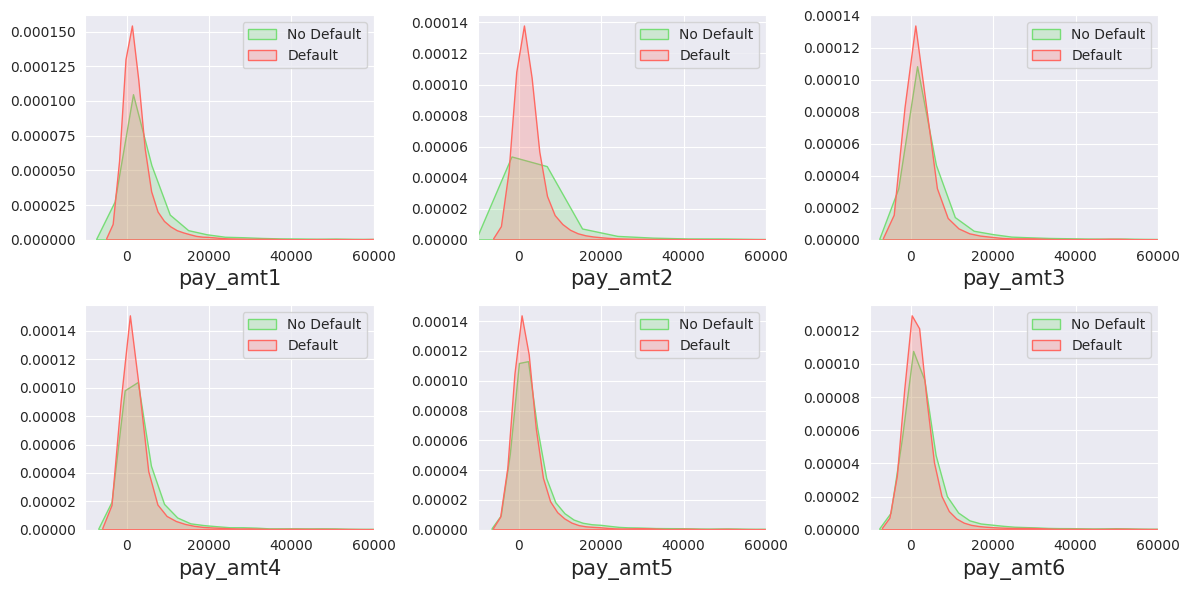

In [ ]:
pay_amt_cols = ['pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']

plt.figure(figsize=(12, 6))

for i, col in enumerate(pay_amt_cols):
    plt.subplot(2, 3, i + 1)

    sns.kdeplot(
        df.loc[df['default_next_month'] == 0, col],
        label='No Default',
        fill=True,
        color='#77DD76'
    )

    sns.kdeplot(
        df.loc[df['default_next_month'] == 1, col],
        label='Default',
        fill=True,
        color='#FF6962'
    )

    plt.xlim(-10000, 60000)
    plt.xlabel(col, fontsize=15)
    plt.ylabel('')
    plt.legend()
    plt.tight_layout()

In [ ]:
target_col = "default_next_month"

X = df[standard_feature_names].copy()
y = df[target_col].copy()

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (29601, 23)
Shape of y: (29601,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training data shape: (23680, 23)
Testing data shape: (5921, 23)

Training target distribution:
default_next_month
0    0.777
1    0.223
Name: proportion, dtype: float64

Testing target distribution:
default_next_month
0    0.777
1    0.223
Name: proportion, dtype: float64


In [ ]:
categorical_cols = ["sex", "education", "marriage"]

numeric_cols = [
    col for col in standard_feature_names
    if col not in categorical_cols
]

def make_preprocessor():
    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", onehot, categorical_cols),
            ("num", StandardScaler(), numeric_cols)
        ]
    )

    return preprocessor

In [ ]:
preprocessor = make_preprocessor()

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Prepared training shape:", X_train_prepared.shape)
print("Prepared testing shape:", X_test_prepared.shape)

Prepared training shape: (23680, 29)
Prepared testing shape: (5921, 29)


In [ ]:
results = []

def evaluate_model(model_name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_data)[:, 1]
        roc_auc = roc_auc_score(y_test_data, y_proba)
    else:
        y_proba = None
        roc_auc = np.nan

    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred)
    rec = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nClassification Report:")
    print(classification_report(y_test_data, y_pred, target_names=["No Default", "Default"]))

    ConfusionMatrixDisplay.from_predictions(
        y_test_data,
        y_pred,
        display_labels=["No Default", "Default"],
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    if y_proba is not None:
        RocCurveDisplay.from_predictions(y_test_data, y_proba)
        plt.title(f"ROC Curve - {model_name}")
        plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    }

Logistic Regression Without Balancing
Accuracy : 0.8105
Precision: 0.7236
Recall   : 0.2438
F1-score : 0.3647
ROC-AUC  : 0.725

Classification Report:
              precision    recall  f1-score   support

  No Default       0.82      0.97      0.89      4600
     Default       0.72      0.24      0.36      1321

    accuracy                           0.81      5921
   macro avg       0.77      0.61      0.63      5921
weighted avg       0.80      0.81      0.77      5921



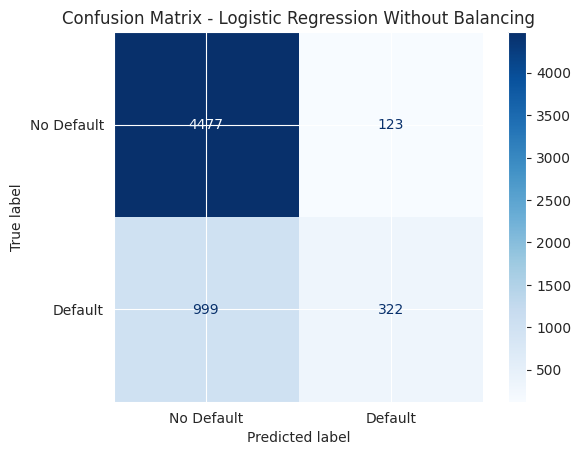

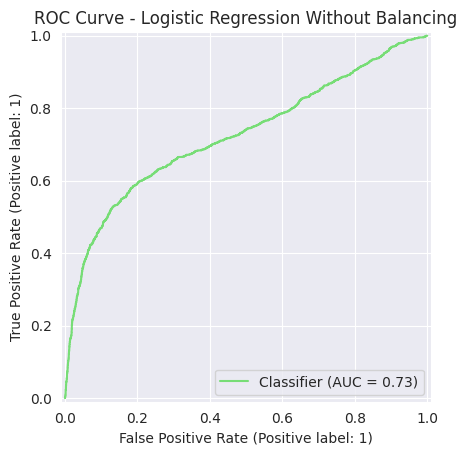

In [ ]:
log_reg_without_balance = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg_without_balance.fit(X_train_prepared, y_train)

result = evaluate_model(
    "Logistic Regression Without Balancing",
    log_reg_without_balance,
    X_test_prepared,
    y_test
)

results.append(result)

In [ ]:
from imblearn.over_sampling import RandomOverSampler

In [ ]:
ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

print("Before balancing:")
print(y_train.value_counts())

print("\nAfter balancing:")
print(y_train_balanced.value_counts())

Before balancing:
default_next_month
0    18396
1     5284
Name: count, dtype: int64

After balancing:
default_next_month
0    18396
1    18396
Name: count, dtype: int64


In [ ]:
preprocessor_balanced = make_preprocessor()

X_train_balanced_prepared = preprocessor_balanced.fit_transform(X_train_balanced)
X_test_balanced_prepared = preprocessor_balanced.transform(X_test)

print("Balanced prepared training shape:", X_train_balanced_prepared.shape)
print("Prepared testing shape:", X_test_balanced_prepared.shape)

Balanced prepared training shape: (36792, 29)
Prepared testing shape: (5921, 29)


Logistic Regression With Balancing
Accuracy : 0.6904
Precision: 0.3858
Recall   : 0.6548
F1-score : 0.4855
ROC-AUC  : 0.725

Classification Report:
              precision    recall  f1-score   support

  No Default       0.88      0.70      0.78      4600
     Default       0.39      0.65      0.49      1321

    accuracy                           0.69      5921
   macro avg       0.63      0.68      0.63      5921
weighted avg       0.77      0.69      0.71      5921



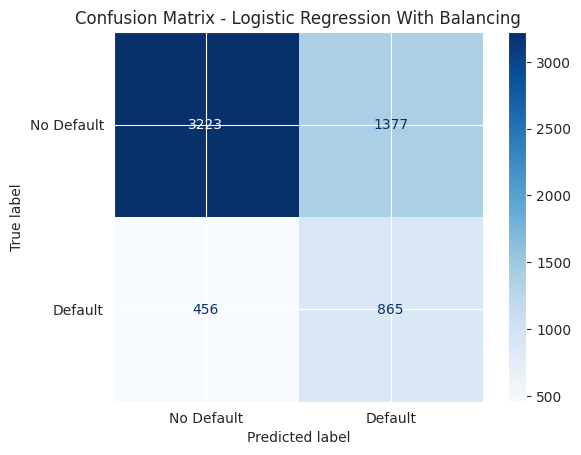

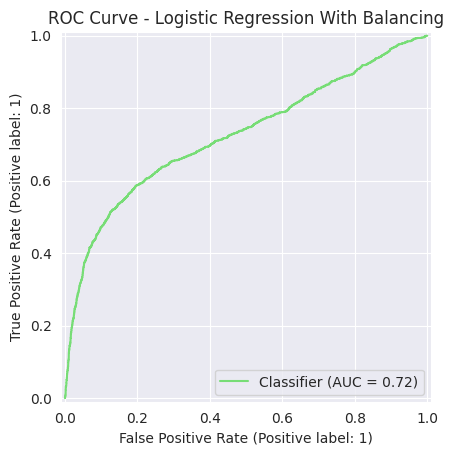

In [ ]:
log_reg_with_balance = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg_with_balance.fit(X_train_balanced_prepared, y_train_balanced)

result = evaluate_model(
    "Logistic Regression With Balancing",
    log_reg_with_balance,
    X_test_balanced_prepared,
    y_test
)

results.append(result)